In [112]:
# This file is visualizing the results of the scoping review. 



In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
import numpy as np
import openpyxl

In [114]:
print("hello world")

hello world


In [115]:
file_path = Path(
    "/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/Extraction information for visualization.xlsx"
)

column_name = "Health/Clinical Domain Simplified"

df = pd.read_excel(file_path)

# Make sure the column exists
if column_name not in df.columns:
    raise ValueError(
        f"Column '{column_name}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )


# Give each study a unique ID
df = df.reset_index(drop=True)
df["Study_ID"] = df.index + 1

In [116]:

# This plots the clinical health domains across the studies

# ============================================================
# 3. FUNCTION TO SPLIT MULTIPLE DOMAINS
# ============================================================
# This splits on commas ONLY when the comma is outside parentheses.
#
# Example: "Oncology, Neurology, Critical care" becomes: Oncology, NeurologyCritical care
#
# But: "Health and well-being / physical activity (fitness, sport)" stays together.

def split_domains(text):
    if pd.isna(text):
        return []

    text = str(text).strip()

    # Split commas that are NOT inside parentheses
    return [
        x.strip()
        for x in re.split(r",\s*(?![^()]*\))", text)
        if x.strip()
    ]


# Split and explode into one domain per row
domain_df = df[["Study_ID", column_name]].copy()

domain_df["Domain_raw"] = domain_df[column_name].apply(split_domains)

domain_df = domain_df.explode("Domain_raw")

domain_df["Domain_raw"] = domain_df["Domain_raw"].str.strip()



In [117]:
# ============================================================
# 4. STANDARDIZE DOMAIN NAMES
# ============================================================

def standardize_domain(domain):

    if pd.isna(domain):
        return None

    d = domain.strip().lower()

    if "mental health" in d:
        return "Mental health"

    if "multi-domain" in d or "whole-body" in d:
        return "Multi-domain / whole-body"

    if "microbiome" in d or "pharmacomicrobiomics" in d:
        return "Gut microbiome / pharmacomicrobiomics"

    if "neurolog" in d:
        return "Neurology"

    if (
        "critical care" in d
        or "intensive care" in d
        or "emergency" in d
        or "rapid response" in d
    ):
        return "Critical / emergency care"

    if "cardiovascular" in d:
        return "Cardiovascular"

    # --------------------------------------------------------
    # Oncology
    # --------------------------------------------------------
    if "oncolog" in d:
        return "Oncology"

    if (
        "wellness" in d
        or "well-being" in d
        or "wellbeing" in d
        or "physical activity" in d
        or "fitness" in d
        or "lifestyle" in d
    ):
        return "Health, fitness & wellness"

    if "endocrine" in d or "metabolic" in d:
        return "Endocrine / metabolic"


    if "respiratory" in d:
        return "Respiratory"

    if "surgical" in d or "perioperative" in d:
        return "Surgical / perioperative"

    return domain.strip()


domain_df["Domain"] = domain_df["Domain_raw"].apply(
    standardize_domain
)

# Remove missing domains
domain_df = domain_df.dropna(subset=["Domain"])


Number of studies: 18

Domain counts:
                               Domain  Count   Percent
                            Neurology      5 27.777778
            Critical / emergency care      3 16.666667
           Health, fitness & wellness      3 16.666667
            Multi-domain / whole-body      3 16.666667
                             Oncology      3 16.666667
                       Cardiovascular      2 11.111111
                Endocrine / metabolic      1  5.555556
Gut microbiome / pharmacomicrobiomics      1  5.555556
                        Mental health      1  5.555556
                          Respiratory      1  5.555556
             Surgical / perioperative      1  5.555556


Original-to-standardized domain mapping:
                                                         Domain_raw                                Domain
                                                     Cardiovascular                        Cardiovascular
                                     Critical 

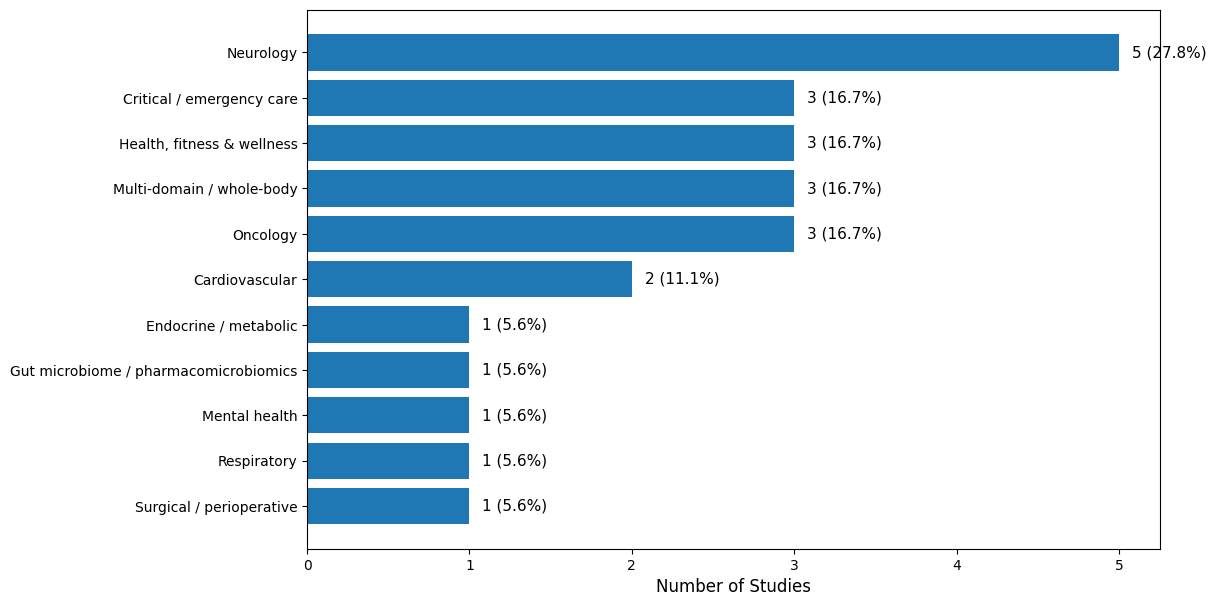

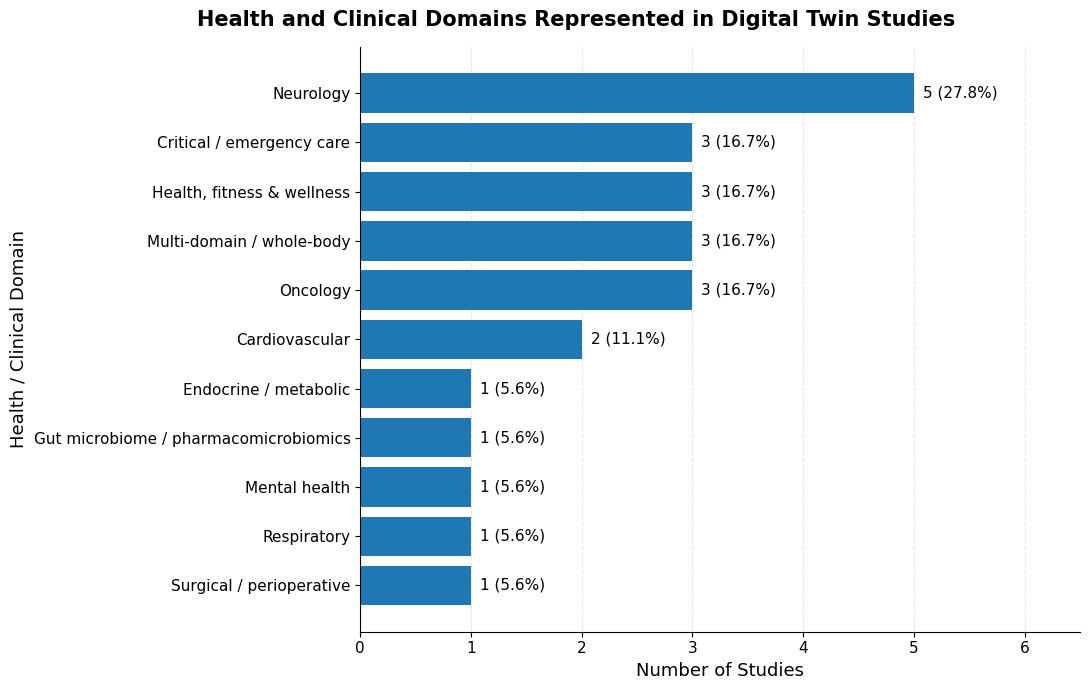


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/clinical_domain_distribution.png


<Figure size 640x480 with 0 Axes>


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/clinical_domain_distribution.png


In [118]:
# 5. PREVENT DOUBLE-COUNTING WITHIN A STUDY
# ============================================================
# If one study somehow lists the same standardized domain twice, it should still only count once.

domain_df = domain_df.drop_duplicates(
    subset=["Study_ID", "Domain"]
)

# 6. COUNT DOMAINS
# ============================================================

domain_counts = (
    domain_df
    .groupby("Domain")
    .agg(Count=("Study_ID", "nunique")).reset_index())

# Number of studies with domain information
n_studies = df[column_name].notna().sum()

domain_counts["Percent"] = (
    domain_counts["Count"] / n_studies * 100
)

# Sort largest to smallest
domain_counts = domain_counts.sort_values(
    by=["Count", "Domain"],
    ascending=[False, True]
).reset_index(drop=True)


# 7. PRINT RESULTS
# ============================================================

print("\nNumber of studies:", n_studies)

print("\nDomain counts:")
print(domain_counts.to_string(index=False))


# Also print the original -> standardized mapping
# so you can check that the cleaning is correct
print("\n\nOriginal-to-standardized domain mapping:")

mapping_check = (
    domain_df[["Domain_raw", "Domain"]]
    .drop_duplicates()
    .sort_values(["Domain", "Domain_raw"])
)

print(mapping_check.to_string(index=False))


# 8. CREATE HORIZONTAL BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    domain_counts["Domain"],
    domain_counts["Count"])

# Largest count at top
ax.invert_yaxis()

# 9. ADD COUNT + PERCENTAGE LABELS
# ============================================================

for bar, count, percent in zip(
    bars,
    domain_counts["Count"],
    domain_counts["Percent"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)

# 10. FORMAT PLOT
# ============================================================

ax.set_xlabel("Number of Studies",fontsize=12)

# 6. COUNT DOMAINS
# ============================================================

domain_counts = (
    domain_df
    .groupby("Domain")
    .agg(
        Count=("Study_ID", "nunique")
    ).reset_index())

# Number of studies with domain information
n_studies = df[column_name].notna().sum()

domain_counts["Percent"] = (domain_counts["Count"] / n_studies * 100)

# Sort largest to smallest
domain_counts = domain_counts.sort_values(
    by=["Count", "Domain"],
    ascending=[False, True]
).reset_index(drop=True)

# 7. PRINT RESULTS
# ============================================================

print("\nNumber of studies:", n_studies)

print("\nDomain counts:")
print(domain_counts.to_string(index=False))


# Also print the original -> standardized mapping
# so you can check that the cleaning is correct
print("\n\nOriginal-to-standardized domain mapping:")

mapping_check = (
    domain_df[["Domain_raw", "Domain"]]
    .drop_duplicates()
    .sort_values(["Domain", "Domain_raw"])
)

print(mapping_check.to_string(index=False))

# 8. CREATE HORIZONTAL BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    domain_counts["Domain"],
    domain_counts["Count"])

# Largest count at top
ax.invert_yaxis()

# 9. ADD COUNT + PERCENTAGE LABELS
# ============================================================

for bar, count, percent in zip(
    bars,
    domain_counts["Count"],
    domain_counts["Percent"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11
    )


# ============================================================
# 10. FORMAT PLOT
# ============================================================

ax.set_xlabel("Number of Studies",fontsize=13)

ax.set_ylabel("Health / Clinical Domain",fontsize=13)

ax.set_title(
    "Health and Clinical Domains Represented in Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    x=0.3)

ax.tick_params(axis="x",labelsize=11)

ax.tick_params(axis="y",labelsize=11)

# Force integer x-axis
max_count = domain_counts["Count"].max()

ax.set_xticks(range(0, max_count + 2))

# Give room for labels at end of bars
ax.set_xlim(0,max_count + 1.5)

# Grid
ax.grid(axis="x",linestyle="--",alpha=0.3)

ax.set_axisbelow(True)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


# ============================================================
# 11. SAVE FIGURE
# ============================================================

output_path = file_path.parent / "clinical_domain_distribution.png"

plt.savefig(output_path,dpi=600,bbox_inches="tight")

plt.show()

print(f"\nFigure saved to:\n{output_path}")


ax.set_ylabel(
    "Health / Clinical Domain",
    fontsize=12)

ax.set_title(
    "Health and Clinical Domains Within the Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    x = 0.3)

ax.tick_params(axis="x",labelsize=11)

ax.tick_params(axis="y",labelsize=11)

# Force integer x-axis
max_count = domain_counts["Count"].max()

ax.set_xticks(range(0, max_count + 2))

# Give room for labels at end of bars
ax.set_xlim(0,max_count + 1.5)

# Grid
ax.grid(axis="x",linestyle="--",alpha=0.3)

ax.set_axisbelow(True)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


# 11. SAVE FIGURE
# ============================================================

output_path = file_path.parent / "clinical_domain_distribution.png"

# plt.savefig(
#     output_path,
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

print(f"\nFigure saved to:\n{output_path}")

In [119]:
# ==========================================

# Time to do it for the Study Type Category


# ==========================================

In [120]:
study_type_column = "Study Type Category"

# 2. READ EXCEL FILE
# ============================================================

# df is the worksheet as a dataframe. I extracted it in the earlier part of the notebook, so we don't need to read it again.
# Make sure the column exists
if study_type_column not in df.columns:
    raise ValueError(
        f"Column '{study_type_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# Give each study a unique ID
df = df.reset_index(drop=True)
df["Study_ID"] = df.index + 1

# 3. SPLIT STUDIES WITH MULTIPLE STUDY TYPES
# ============================================================
# Since your categories are fixed and separated by commas, we can simply split on commas.

study_type_df = df[["Study_ID", study_type_column]].copy()

study_type_df["Study_Type"] = (
    study_type_df[study_type_column]
    .fillna("")
    .str.split(","))

# Put each study type on its own row
study_type_df = study_type_df.explode("Study_Type")

# Remove leading/trailing spaces
study_type_df["Study_Type"] = (
    study_type_df["Study_Type"]
    .str.strip())

# Remove empty rows
study_type_df = study_type_df[
    study_type_df["Study_Type"] != ""]



In [121]:
# 4. OPTIONAL: STANDARDIZE EXTRA WHITESPACE
# ============================================================
# This fixes things such as:
# "Model development with   performance evaluation" becoming "Model development with performance evaluation"

study_type_df["Study_Type"] = (
    study_type_df["Study_Type"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 5. PREVENT DOUBLE-COUNTING WITHIN A STUDY
# ============================================================
# If the same study type somehow appears twice within one study, count it only once.
# This exists but not needed as this never happened in the data, but it's a good safety check.

study_type_df = study_type_df.drop_duplicates(
    subset=["Study_ID", "Study_Type"])

# ============================================================
# 6. COUNT STUDY TYPES
# ============================================================

study_type_counts = (
    study_type_df
    .groupby("Study_Type")
    .agg(Count=("Study_ID", "nunique"))
    .reset_index())

# Number of studies with study-type information
n_studies = df[study_type_column].notna().sum()

# Percentage of included studies
study_type_counts["Percent"] = (study_type_counts["Count"] / n_studies * 100)


# Sort from largest to smallest
study_type_counts = study_type_counts.sort_values(
    by=["Count", "Study_Type"],
    ascending=[False, True]
).reset_index(drop=True)


# ============================================================
# 7. PRINT RESULTS
# ============================================================

print("\nNumber of studies:", n_studies)

print("\nStudy Type Counts:")
print(study_type_counts.to_string(index=False))


# ============================================================
# 8. CHECK UNIQUE CATEGORIES
# ============================================================
# This is useful to make sure Excel does not contain any
# spelling or spacing inconsistencies.

print("\nUnique Study Type Categories:")

for category in sorted(study_type_df["Study_Type"].unique()):
    print(category)



Number of studies: 18

Study Type Counts:
                                   Study_Type  Count   Percent
             System/prototype with evaluation     13 72.222222
Model development with performance evaluation     12 66.666667
                          Human-subject study      9 50.000000
                 Observational/clinical study      2 11.111111
          System/prototype without evaluation      1  5.555556

Unique Study Type Categories:
Human-subject study
Model development with performance evaluation
Observational/clinical study
System/prototype with evaluation
System/prototype without evaluation


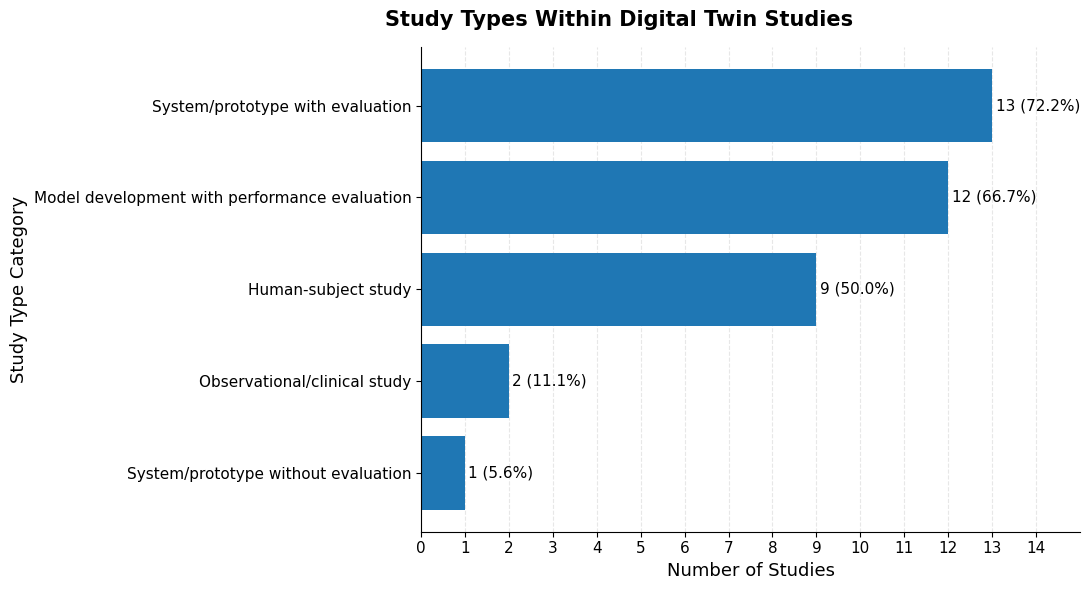


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/study_type_category_distribution.png


In [122]:
# ============================================================
# 9. CREATE HORIZONTAL BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    study_type_counts["Study_Type"],
    study_type_counts["Count"]
)

# Largest category at top
ax.invert_yaxis()

# ============================================================
# 10. ADD COUNT + PERCENTAGE LABELS
# ============================================================

for bar, count, percent in zip(
    bars,
    study_type_counts["Count"],
    study_type_counts["Percent"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)


# ============================================================
# 11. FORMAT PLOT
# ============================================================

ax.set_xlabel("Number of Studies",fontsize=13)

ax.set_ylabel("Study Type Category",fontsize=13)

ax.set_title(
    "Study Types Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    x = 0.3
    #loc="center"
)

ax.tick_params(axis="x",labelsize=11)

ax.tick_params(axis="y",labelsize=11)

# Integer x-axis
max_count = study_type_counts["Count"].max()

ax.set_xticks(range(0, max_count + 2))

# Give room for labels at ends of bars
ax.set_xlim(0,max_count + 2)

# Grid
ax.grid(axis="x",linestyle="--", alpha=0.3)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ============================================================
# 12. SAVE FIGURE
# ============================================================

output_path = (
    file_path.parent /
    "study_type_category_distribution.png")

# plt.savefig(
#     output_path,
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

print(f"\nFigure saved to:\n{output_path}")

In [123]:
# ============================================================
# HUMAN-SUBJECT METHOD
# ============================================================

human_method_column = "Human-Subject Method"


# ============================================================
# 1. MAKE SURE COLUMN EXISTS
# ============================================================

if human_method_column not in df.columns:
    raise ValueError(
        f"Column '{human_method_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")


# ============================================================
# 2. PREPARE DATA
# ============================================================

human_method_df = df[
    ["Study_ID", human_method_column]
].copy()


# Convert to string and clean whitespace
human_method_df[human_method_column] = (
    human_method_df[human_method_column]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# ============================================================
# 3. REMOVE NA / NOT APPLICABLE
# ============================================================

non_applicable_values = ["NA","N/A","Not applicable","Not Applicable",""]

human_method_df = human_method_df[
    ~human_method_df[human_method_column].isin(
        non_applicable_values)]

human_method_df = human_method_df.dropna(
    subset=[human_method_column])


# ============================================================
# 4. NUMBER OF STUDIES WITH A HUMAN-SUBJECT METHOD
# ============================================================

n_human_subject_studies = (
    human_method_df["Study_ID"].nunique())

print(
    "\nNumber of studies with a human-subject method:",
    n_human_subject_studies)

# ============================================================
# 5. SPLIT MULTIPLE METHODS
# ============================================================

human_method_df["Human_Subject_Method"] = (
    human_method_df[human_method_column].str.split(","))

# One method per row
human_method_df = human_method_df.explode("Human_Subject_Method")

# Clean whitespace again
human_method_df["Human_Subject_Method"] = (
    human_method_df["Human_Subject_Method"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())


# ============================================================
# 6. PREVENT DOUBLE-COUNTING WITHIN A STUDY
# ============================================================

human_method_df = human_method_df.drop_duplicates(
    subset=["Study_ID", "Human_Subject_Method"])


# ============================================================
# 7. COUNT METHODS
# ============================================================

human_method_counts = (
    human_method_df
    .groupby("Human_Subject_Method")
    .agg(Count=("Study_ID", "nunique")).reset_index())


# Calculate percentage
human_method_counts["Percent"] = (
    human_method_counts["Count"]
    / n_human_subject_studies
    * 100)


# Sort largest to smallest
human_method_counts = human_method_counts.sort_values(
    by=["Count", "Human_Subject_Method"],
    ascending=[False, True]
).reset_index(drop=True)


# ============================================================
# 8. PRINT RESULTS
# ============================================================

print("\nHuman-Subject Method Counts:")

print(human_method_counts.to_string(index=False))


print("\nUnique Human-Subject Methods:")

for method in sorted(
    human_method_df[
        "Human_Subject_Method"
    ].unique()):
    print(method)




Number of studies with a human-subject method: 10

Human-Subject Method Counts:
    Human_Subject_Method  Count  Percent
              Experiment      5     50.0
                  Survey      5     50.0
          Usability test      4     40.0
               Interview      2     20.0
Observational monitoring      1     10.0

Unique Human-Subject Methods:
Experiment
Interview
Observational monitoring
Survey
Usability test


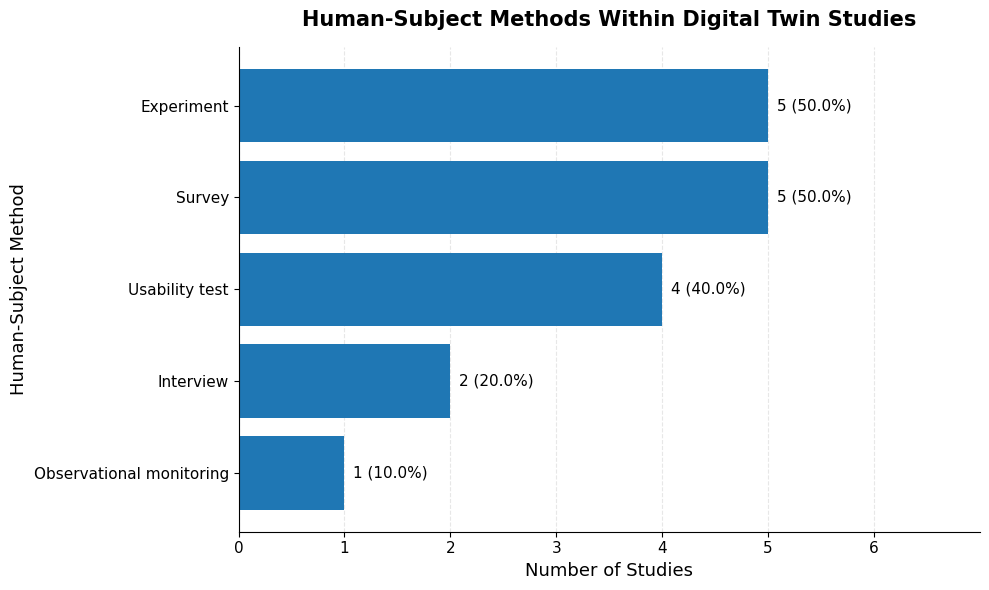


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/human_subject_method_distribution.png


In [124]:

# ============================================================
# 9. CREATE HORIZONTAL BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6))

bars = ax.barh(
    human_method_counts[
        "Human_Subject_Method"
    ],
    human_method_counts["Count"])

# Largest category at top
ax.invert_yaxis()

# ============================================================
# 10. ADD COUNT + PERCENTAGE LABELS
# ============================================================

for bar, count, percent in zip(
    bars,
    human_method_counts["Count"],
    human_method_counts["Percent"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y()
        + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)

# ============================================================
# 11. FORMAT PLOT
# ============================================================

ax.set_xlabel("Number of Studies",fontsize=13)

ax.set_ylabel("Human-Subject Method",fontsize=13)

ax.set_title(
    "Human-Subject Methods Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(axis="x",labelsize=11)

ax.tick_params(axis="y",labelsize=11)

# Force integer x-axis
max_count = (human_method_counts["Count"].max())

ax.set_xticks(
    range(0, max_count + 2))

# Give room for text labels
ax.set_xlim(0,max_count + 2)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# ============================================================
# 12. SAVE FIGURE
# ============================================================

output_path = (
    file_path.parent
    / "human_subject_method_distribution.png"
)

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(f"\nFigure saved to:\n{output_path}")

In [125]:
# User/Stakeholder Type

stakeholder_column = "User/Stakeholder Type Modified"

# 1. Make sure column exists

if stakeholder_column not in df.columns:
    raise ValueError(
        f"Column '{stakeholder_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

stakeholder_df = df[["Study_ID", stakeholder_column]].copy()

stakeholder_df[stakeholder_column] = (
    stakeholder_df[stakeholder_column]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 3. Clean special stakeholder descriptions

stakeholder_df[stakeholder_column] = stakeholder_df[
    stakeholder_column
].replace({
    "Other; Learner/trainee (medical & health science students), with instructors/educators as secondary.":
        "Learner/trainee, Instructor/educator"
})

# 4. Remove missing values

stakeholder_df = stakeholder_df.dropna(subset=[stakeholder_column])

stakeholder_df = stakeholder_df[
    ~stakeholder_df[stakeholder_column].isin(
        ["NA", "N/A", "Not applicable", ""])]

# 5. Number of studies with stakeholder information

n_stakeholder_studies = (stakeholder_df["Study_ID"].nunique())

print("\nNumber of studies with stakeholder information:",n_stakeholder_studies)

# 6. Split multiple stakeholder types

stakeholder_df["Stakeholder_Type"] = (stakeholder_df[stakeholder_column].str.split(","))

stakeholder_df = stakeholder_df.explode("Stakeholder_Type")

stakeholder_df["Stakeholder_Type"] = (
    stakeholder_df["Stakeholder_Type"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 7. Prevent double-counting within a study

stakeholder_df = stakeholder_df.drop_duplicates(
    subset=["Study_ID", "Stakeholder_Type"])

# 8. Count stakeholder types

stakeholder_counts = (
    stakeholder_df
    .groupby("Stakeholder_Type")
    .agg(Count=("Study_ID", "nunique")).reset_index())

stakeholder_counts["Percent"] = (stakeholder_counts["Count"] / n_stakeholder_studies * 100)

stakeholder_counts = stakeholder_counts.sort_values(
    by=["Count", "Stakeholder_Type"],ascending=[False, True]).reset_index(drop=True)




Number of studies with stakeholder information: 18



User/Stakeholder Type Counts:
               Stakeholder_Type  Count   Percent
            Clinician/care team     13 72.222222
                        Patient      5 27.777778
           Researcher (as user)      3 16.666667
                      Caregiver      2 11.111111
   Health system operator/admin      2 11.111111
                        Coaches      1  5.555556
Consumer wellness platform user      1  5.555556
General consumer / fitness user      1  5.555556
               Individual users      1  5.555556
            Instructor/educator      1  5.555556
                Learner/trainee      1  5.555556

Unique User/Stakeholder Types:
Caregiver
Clinician/care team
Coaches
Consumer wellness platform user
General consumer / fitness user
Health system operator/admin
Individual users
Instructor/educator
Learner/trainee
Patient
Researcher (as user)


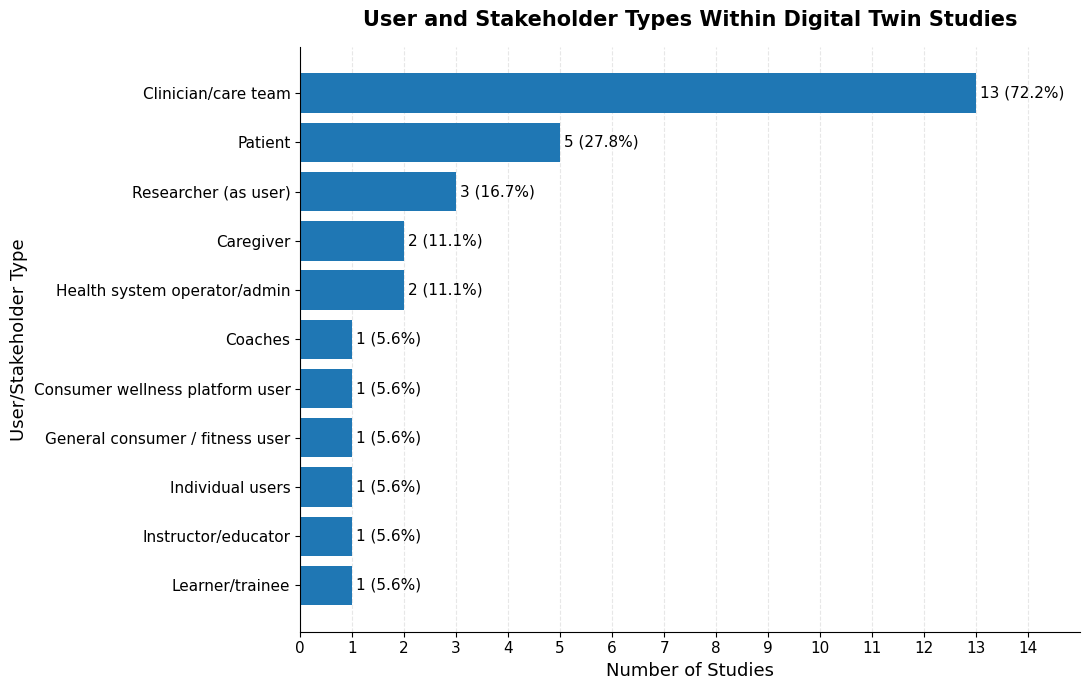


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/user_stakeholder_type_distribution.png


In [126]:
# 9. Print results

print("\nUser/Stakeholder Type Counts:")

print(stakeholder_counts.to_string(index=False))

print("\nUnique User/Stakeholder Types:")

for stakeholder in sorted(
    stakeholder_df["Stakeholder_Type"].unique()):
    print(stakeholder)

# 10. Create horizontal bar chart

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    stakeholder_counts["Stakeholder_Type"],
    stakeholder_counts["Count"])

ax.invert_yaxis()

# 11. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    stakeholder_counts["Count"],
    stakeholder_counts["Percent"]
):

    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)

# 12. Format plot

ax.set_xlabel("Number of Studies",fontsize=13)

ax.set_ylabel("User/Stakeholder Type",fontsize=13)

ax.set_title(
    "User and Stakeholder Types Within Digital Twin Studies",
    fontsize=15,fontweight="bold",pad=15,
    loc="center"
)

ax.tick_params(axis="x",labelsize=11)

ax.tick_params(axis="y",labelsize=11)

max_count = stakeholder_counts["Count"].max()

ax.set_xticks(range(0, max_count + 2))

ax.set_xlim(0,max_count + 2)

ax.grid(axis="x",linestyle="--",alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 13. Save figure

output_path = (file_path.parent / "user_stakeholder_type_distribution.png")

plt.savefig(output_path,dpi=600,bbox_inches="tight")

plt.show()

print(f"\nFigure saved to:\n{output_path}")


Number of studies: 18

AI/Agent Component Described:
AI_Component  Count   Percent
         Yes     17 94.444444
          No      1  5.555556


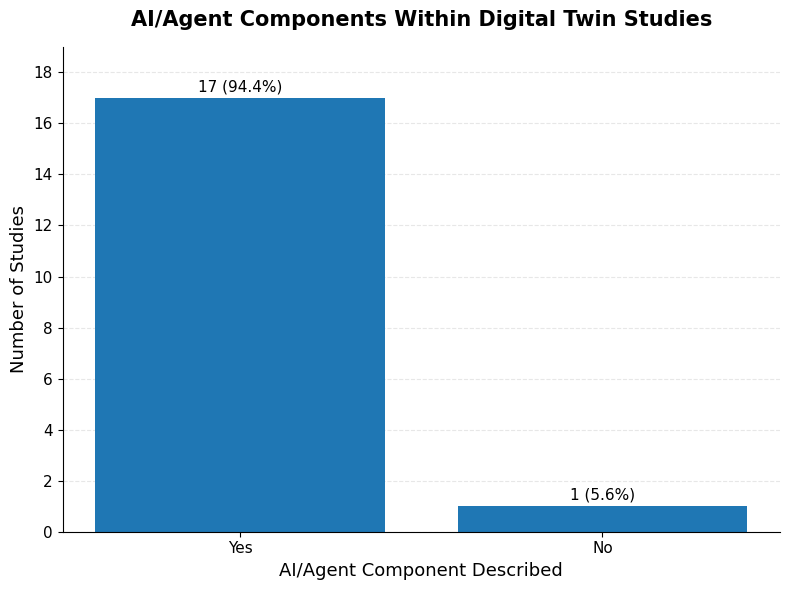


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/ai_agent_component_described.png


In [127]:
 # AI/Agent Component Described

ai_component_column = "AI/Agent Component Described Y/N"

# 1. Make sure column exists

if ai_component_column not in df.columns:
    raise ValueError(
        f"Column '{ai_component_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

ai_component_df = df[
    ["Study_ID", ai_component_column]
].copy()

ai_component_df[ai_component_column] = (
    ai_component_df[ai_component_column]
    .astype("string")
    .str.strip()
    .str.upper())

# Remove missing values

ai_component_df = ai_component_df.dropna(
    subset=[ai_component_column])

ai_component_df = ai_component_df[
    ~ai_component_df[ai_component_column].isin(
        ["NA", "N/A", "NOT APPLICABLE", ""])]

# 3. Count responses

n_studies = ai_component_df["Study_ID"].nunique()

ai_component_counts = (
    ai_component_df
    .groupby(ai_component_column)
    .agg(
        Count=("Study_ID", "nunique"))
    .reset_index())

ai_component_counts["Percent"] = (
    ai_component_counts["Count"]
    / n_studies
    * 100)

# Make Y appear before N

category_order = ["Y", "N"]

ai_component_counts[ai_component_column] = pd.Categorical(
    ai_component_counts[ai_component_column],
    categories=category_order,
    ordered=True)

ai_component_counts = (
    ai_component_counts
    .sort_values(ai_component_column)
    .reset_index(drop=True))

# 4. Rename categories for plotting

ai_component_counts["AI_Component"] = (
    ai_component_counts[ai_component_column]
    .map({
        "Y": "Yes",
        "N": "No"}))

# 5. Print results

print("\nNumber of studies:", n_studies)

print("\nAI/Agent Component Described:")
print(
    ai_component_counts[
        ["AI_Component", "Count", "Percent"]
    ].to_string(index=False))

# 6. Create bar chart

fig, ax = plt.subplots(
    figsize=(8, 6))

bars = ax.bar(
    ai_component_counts["AI_Component"],
    ai_component_counts["Count"])

# 7. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    ai_component_counts["Count"],
    ai_component_counts["Percent"]):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{count} ({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11)

# 8. Format plot

ax.set_xlabel(
    "AI/Agent Component Described",
    fontsize=13)

ax.set_ylabel(
    "Number of Studies",
    fontsize=13)

ax.set_title(
    "AI/Agent Components Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(
    axis="both",
    labelsize=11)

max_count = ai_component_counts["Count"].max()

ax.set_yticks(
    range(0, max_count + 3, 2))

ax.set_ylim(
    0,
    max_count + 2)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 9. Save figure

output_path = (
    file_path.parent
    / "ai_agent_component_described.png")

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(
    f"\nFigure saved to:\n{output_path}")


Number of studies reporting an AI/agent component type: 17

AI/Agent Component Type Counts:
                       AI_Component_Type  Count   Percent
                              Prediction     15 88.235294
Decision support (incl. LLM/multi-agent)      9 52.941176
                             Explanation      8 47.058824
                              Simulation      7 41.176471
                          Recommendation      6 35.294118

Unique AI/Agent Component Types:
Decision support (incl. LLM/multi-agent)
Explanation
Prediction
Recommendation
Simulation


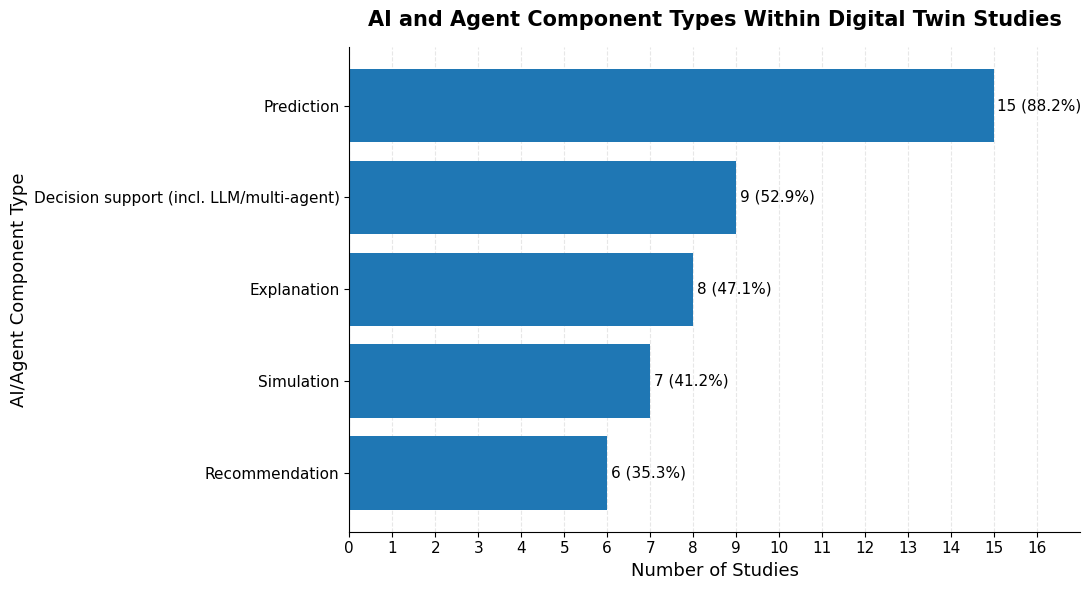


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/ai_agent_component_type_distribution.png


In [128]:
# AI/Agent Component Type(s)

ai_type_column = "AI/Agent Component Type(s) Modified"

# 1. Make sure column exists

if ai_type_column not in df.columns:
    raise ValueError(
        f"Column '{ai_type_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

ai_type_df = df[
    ["Study_ID", ai_type_column]
].copy()

ai_type_df[ai_type_column] = (
    ai_type_df[ai_type_column]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 3. Remove NA / Not applicable

ai_type_df = ai_type_df.dropna(
    subset=[ai_type_column])

ai_type_df = ai_type_df[
    ~ai_type_df[ai_type_column].isin(
        ["NA", "N/A", "Not applicable", "Not Applicable", ""])]

# 4. Number of studies reporting an AI/agent component type

n_ai_type_studies = ai_type_df["Study_ID"].nunique()

print(
    "\nNumber of studies reporting an AI/agent component type:",
    n_ai_type_studies)

# 5. Split multiple AI/agent component types

ai_type_df["AI_Component_Type"] = (
    ai_type_df[ai_type_column]
    .str.split(","))

ai_type_df = ai_type_df.explode(
    "AI_Component_Type")

ai_type_df["AI_Component_Type"] = (
    ai_type_df["AI_Component_Type"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 6. Prevent double-counting within a study

ai_type_df = ai_type_df.drop_duplicates(
    subset=["Study_ID", "AI_Component_Type"])

# 7. Count AI/agent component types

ai_type_counts = (
    ai_type_df
    .groupby("AI_Component_Type")
    .agg(
        Count=("Study_ID", "nunique"))
    .reset_index())

ai_type_counts["Percent"] = (
    ai_type_counts["Count"]
    / n_ai_type_studies
    * 100)

ai_type_counts = ai_type_counts.sort_values(
    by=["Count", "AI_Component_Type"],
    ascending=[False, True]
).reset_index(drop=True)

# 8. Print results

print("\nAI/Agent Component Type Counts:")

print(
    ai_type_counts.to_string(
        index=False))

print("\nUnique AI/Agent Component Types:")

for ai_type in sorted(
    ai_type_df["AI_Component_Type"].unique()):
    print(ai_type)

# 9. Create horizontal bar chart

fig, ax = plt.subplots(
    figsize=(11, 6))

bars = ax.barh(
    ai_type_counts["AI_Component_Type"],
    ai_type_counts["Count"])

ax.invert_yaxis()

# 10. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    ai_type_counts["Count"],
    ai_type_counts["Percent"]):

    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)

# 11. Format plot

ax.set_xlabel(
    "Number of Studies",
    fontsize=13)

ax.set_ylabel(
    "AI/Agent Component Type",
    fontsize=13)

ax.set_title(
    "AI and Agent Component Types Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(
    axis="x",
    labelsize=11)

ax.tick_params(
    axis="y",
    labelsize=11)

max_count = ai_type_counts["Count"].max()

ax.set_xticks(
    range(0, max_count + 2))

ax.set_xlim(
    0,
    max_count + 2)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 12. Save figure

output_path = (
    file_path.parent
    / "ai_agent_component_type_distribution.png")

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(
    f"\nFigure saved to:\n{output_path}")


Number of studies: 18

Exposure Category Counts:
Exposure Category  Count   Percent
     Interface+AI     16 88.888889
   Interface-only      1  5.555556
          AI-only      1  5.555556


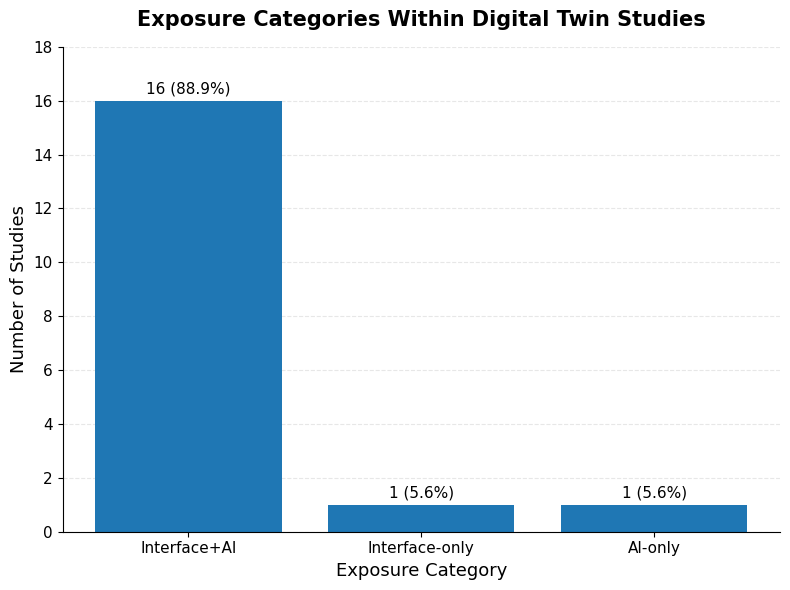


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/exposure_category_distribution.png


In [129]:
# Exposure Category

exposure_column = "Exposure Category"

# 1. Make sure column exists

if exposure_column not in df.columns:
    raise ValueError(
        f"Column '{exposure_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

exposure_df = df[
    ["Study_ID", exposure_column]
].copy()

exposure_df[exposure_column] = (
    exposure_df[exposure_column]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# Remove missing values

exposure_df = exposure_df.dropna(
    subset=[exposure_column])

exposure_df = exposure_df[
    ~exposure_df[exposure_column].isin(
        ["NA", "N/A", "Not applicable", "Not Applicable", ""])]

# 3. Count exposure categories

n_exposure_studies = exposure_df["Study_ID"].nunique()

exposure_counts = (
    exposure_df
    .groupby(exposure_column)
    .agg(
        Count=("Study_ID", "nunique"))
    .reset_index())

exposure_counts["Percent"] = (
    exposure_counts["Count"]
    / n_exposure_studies
    * 100)

# 4. Set preferred category order

category_order = [
    "Interface+AI",
    "Interface-only",
    "AI-only"
]

exposure_counts[exposure_column] = pd.Categorical(
    exposure_counts[exposure_column],
    categories=category_order,
    ordered=True)

exposure_counts = (
    exposure_counts
    .sort_values(exposure_column)
    .reset_index(drop=True))

# 5. Print results

print("\nNumber of studies:", n_exposure_studies)

print("\nExposure Category Counts:")

print(
    exposure_counts.to_string(
        index=False))

# 6. Create vertical bar chart

fig, ax = plt.subplots(
    figsize=(8, 6))

bars = ax.bar(
    exposure_counts[exposure_column],
    exposure_counts["Count"])

# 7. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    exposure_counts["Count"],
    exposure_counts["Percent"]):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{count} ({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11)

# 8. Format plot

ax.set_xlabel(
    "Exposure Category",
    fontsize=13)

ax.set_ylabel(
    "Number of Studies",
    fontsize=13)

ax.set_title(
    "Exposure Categories Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(
    axis="both",
    labelsize=11)

max_count = exposure_counts["Count"].max()

ax.set_yticks(
    range(0, max_count + 3, 2))

ax.set_ylim(
    0,
    max_count + 2)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 9. Save figure

output_path = (
    file_path.parent
    / "exposure_category_distribution.png")

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(
    f"\nFigure saved to:\n{output_path}")


Number of studies: 18

User Adherence Counts:
Adherence  Count   Percent
      Yes      2 11.111111
       No     16 88.888889


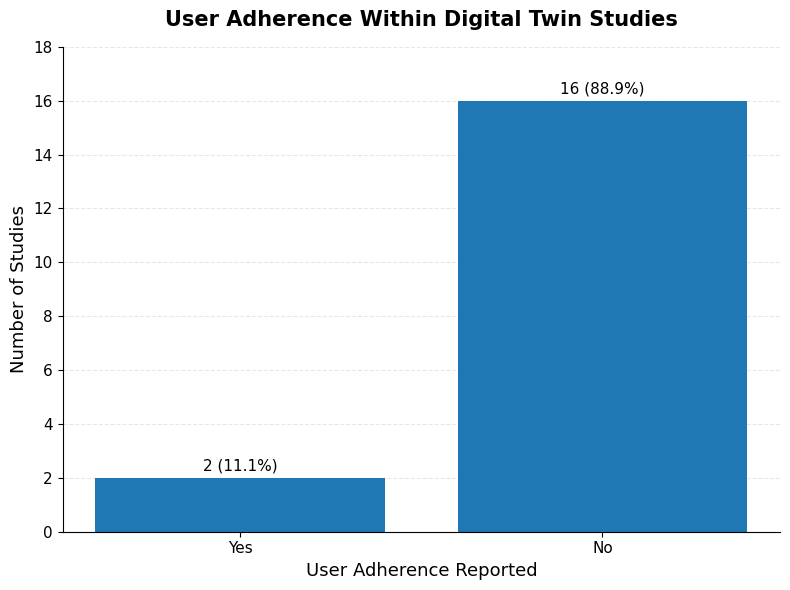


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/user_adherence_distribution.png


In [130]:
# User Adherence

adherence_column = "User Adherence"

# 1. Make sure column exists

if adherence_column not in df.columns:
    raise ValueError(
        f"Column '{adherence_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

adherence_df = df[
    ["Study_ID", adherence_column]
].copy()

adherence_df[adherence_column] = (
    adherence_df[adherence_column]
    .astype("string")
    .str.strip()
    .str.upper())

# Remove missing values

adherence_df = adherence_df.dropna(
    subset=[adherence_column])

adherence_df = adherence_df[
    ~adherence_df[adherence_column].isin(
        ["NA", "N/A", "NOT APPLICABLE", ""])]

# 3. Count responses

n_adherence_studies = adherence_df["Study_ID"].nunique()

adherence_counts = (
    adherence_df
    .groupby(adherence_column)
    .agg(
        Count=("Study_ID", "nunique"))
    .reset_index())

adherence_counts["Percent"] = (
    adherence_counts["Count"]
    / n_adherence_studies
    * 100)

# 4. Set preferred category order

category_order = ["Y", "N"]

adherence_counts[adherence_column] = pd.Categorical(
    adherence_counts[adherence_column],
    categories=category_order,
    ordered=True)

adherence_counts = (
    adherence_counts
    .sort_values(adherence_column)
    .reset_index(drop=True))

# 5. Rename categories for plotting

adherence_counts["Adherence"] = (
    adherence_counts[adherence_column]
    .map({
        "Y": "Yes",
        "N": "No"}))

# 6. Print results

print("\nNumber of studies:", n_adherence_studies)

print("\nUser Adherence Counts:")

print(
    adherence_counts[
        ["Adherence", "Count", "Percent"]
    ].to_string(index=False))

# 7. Create vertical bar chart

fig, ax = plt.subplots(
    figsize=(8, 6))

bars = ax.bar(
    adherence_counts["Adherence"],
    adherence_counts["Count"])

# 8. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    adherence_counts["Count"],
    adherence_counts["Percent"]):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{count} ({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11)

# 9. Format plot

ax.set_xlabel(
    "User Adherence Reported",
    fontsize=13)

ax.set_ylabel(
    "Number of Studies",
    fontsize=13)

ax.set_title(
    "User Adherence Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(
    axis="both",
    labelsize=11)

max_count = adherence_counts["Count"].max()

ax.set_yticks(
    range(0, max_count + 3, 2))

ax.set_ylim(
    0,
    max_count + 2)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 10. Save figure

output_path = (
    file_path.parent
    / "user_adherence_distribution.png")

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(
    f"\nFigure saved to:\n{output_path}")


Number of studies reporting outcomes: 17

Outcome Domain Counts:
                Outcome_Domain  Count   Percent
  Decision support performance     14 82.352941
               Workflow/system     11 64.705882
                  Usability/UX      7 41.176471
               Clinical/health      5 29.411765
                 Human factors      3 17.647059
          Educational outcomes      1  5.882353
Engagement/behavioral outcomes      1  5.882353

Original-to-standardized outcome mapping:
                                                               Outcome_Raw                 Outcome_Domain
                                                           Clinical/health                Clinical/health
                                              Decision support performance   Decision support performance
Educational outcomes (self-reported learner confidence and understanding).           Educational outcomes
            Engagement/behavioral outcomes (retention, adherence, dropout) Engageme

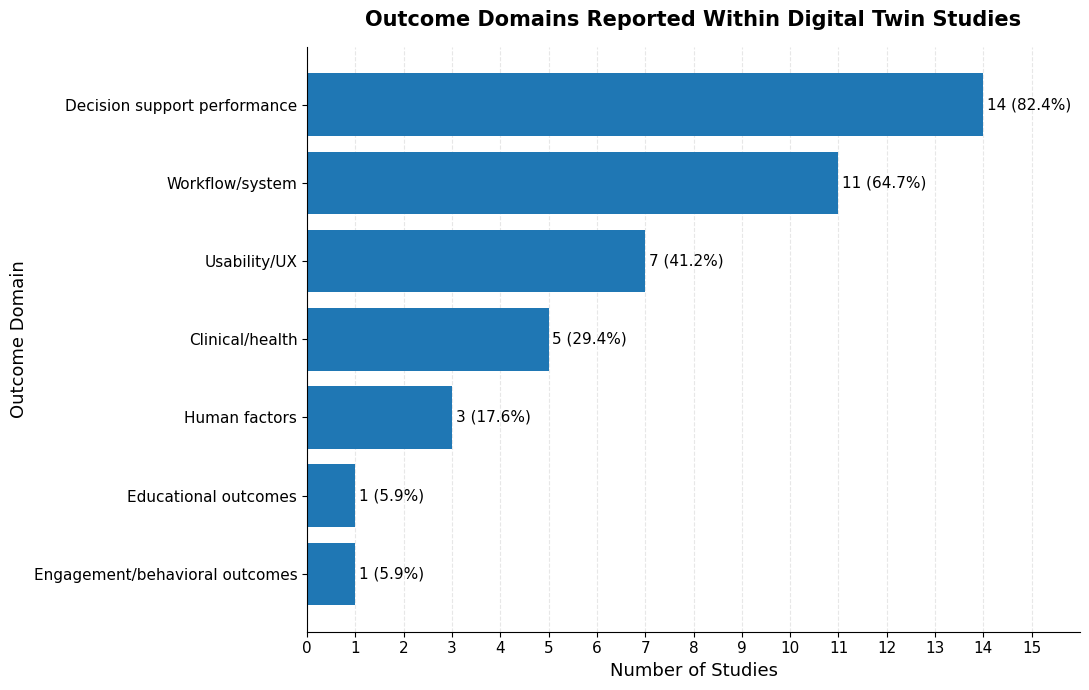


Figure saved to:
/Users/dnartey/Library/CloudStorage/OneDrive-TexasA&MUniversity/PostDoc/Scoping Review/Data Extraction/outcome_domain_distribution.png


In [131]:
# Outcome Domain(s) Reported

outcome_column = "Outcome Domain(s) Reported"

# 1. Make sure column exists

if outcome_column not in df.columns:
    raise ValueError(
        f"Column '{outcome_column}' was not found.\n\n"
        f"Available columns are:\n{df.columns.tolist()}")

# 2. Prepare data

outcome_df = df[
    ["Study_ID", outcome_column]
].copy()

outcome_df[outcome_column] = (
    outcome_df[outcome_column]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 3. Identify studies reporting outcomes

no_outcome_values = [
    "No outcomes reported",
    "NA",
    "N/A",
    "Not applicable",
    "Not Applicable",
    ""
]

reported_outcome_df = outcome_df[
    ~outcome_df[outcome_column].isin(no_outcome_values)
].copy()

reported_outcome_df = reported_outcome_df.dropna(
    subset=[outcome_column])

n_outcome_studies = reported_outcome_df["Study_ID"].nunique()

print(
    "\nNumber of studies reporting outcomes:",
    n_outcome_studies)

# 4. Split multiple outcome domains
# Splits commas outside parentheses only

def split_outcomes(text):
    if pd.isna(text):
        return []

    return [
        x.strip()
        for x in re.split(r",\s*(?![^()]*\))", str(text))
        if x.strip()
    ]

reported_outcome_df["Outcome_Raw"] = (
    reported_outcome_df[outcome_column]
    .apply(split_outcomes))

reported_outcome_df = reported_outcome_df.explode(
    "Outcome_Raw")

reported_outcome_df["Outcome_Raw"] = (
    reported_outcome_df["Outcome_Raw"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# 5. Standardize outcome domains

def standardize_outcome(outcome):

    if pd.isna(outcome):
        return None

    outcome_lower = outcome.lower().strip()

    if outcome_lower.startswith("decision support performance"):
        return "Decision support performance"

    if outcome_lower.startswith("usability/ux"):
        return "Usability/UX"

    if outcome_lower.startswith("workflow/system"):
        return "Workflow/system"

    if outcome_lower.startswith("clinical/health"):
        return "Clinical/health"

    if outcome_lower.startswith("human factors"):
        return "Human factors"

    if outcome_lower.startswith("educational outcomes"):
        return "Educational outcomes"

    if outcome_lower.startswith("expert consensus on model rules"):
        return "Expert consensus on model rules"

    if outcome_lower.startswith("engagement/behavioral outcomes"):
        return "Engagement/behavioral outcomes"

    return outcome.strip()

reported_outcome_df["Outcome_Domain"] = (
    reported_outcome_df["Outcome_Raw"]
    .apply(standardize_outcome))

# 6. Prevent double-counting within a study

reported_outcome_df = reported_outcome_df.drop_duplicates(
    subset=["Study_ID", "Outcome_Domain"])

# 7. Count outcome domains

outcome_counts = (
    reported_outcome_df
    .groupby("Outcome_Domain")
    .agg(
        Count=("Study_ID", "nunique"))
    .reset_index())

outcome_counts["Percent"] = (
    outcome_counts["Count"]
    / n_outcome_studies
    * 100)

outcome_counts = outcome_counts.sort_values(
    by=["Count", "Outcome_Domain"],
    ascending=[False, True]
).reset_index(drop=True)

# 8. Print results

print("\nOutcome Domain Counts:")

print(
    outcome_counts.to_string(
        index=False))

print("\nOriginal-to-standardized outcome mapping:")

mapping_check = (
    reported_outcome_df[
        ["Outcome_Raw", "Outcome_Domain"]
    ]
    .drop_duplicates()
    .sort_values(["Outcome_Domain", "Outcome_Raw"]))

print(
    mapping_check.to_string(
        index=False))

# 9. Create horizontal bar chart

fig, ax = plt.subplots(
    figsize=(11, 7))

bars = ax.barh(
    outcome_counts["Outcome_Domain"],
    outcome_counts["Count"])

ax.invert_yaxis()

# 10. Add count and percentage labels

for bar, count, percent in zip(
    bars,
    outcome_counts["Count"],
    outcome_counts["Percent"]):

    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        ha="left",
        fontsize=11)

# 11. Format plot

ax.set_xlabel(
    "Number of Studies",
    fontsize=13)

ax.set_ylabel(
    "Outcome Domain",
    fontsize=13)

ax.set_title(
    "Outcome Domains Reported Within Digital Twin Studies",
    fontsize=15,
    fontweight="bold",
    pad=15,
    loc="center")

ax.tick_params(
    axis="x",
    labelsize=11)

ax.tick_params(
    axis="y",
    labelsize=11)

max_count = outcome_counts["Count"].max()

ax.set_xticks(
    range(0, max_count + 2))

ax.set_xlim(
    0,
    max_count + 2)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 12. Save figure

output_path = (
    file_path.parent
    / "outcome_domain_distribution.png")

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

print(
    f"\nFigure saved to:\n{output_path}")